In [1]:
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
from scipy.sparse import lil_matrix, csr_matrix

In [3]:
### set pixel size to the mosaic resolution
## everything should work from the mosaic geometry and resolution
pixel_size = 1.017 

In [6]:
dem_path = 'data/MicaDEM_13Aug25_mosext.tif'
# mask_path = '/data/MicaDEM_13Aug25_1mvalidmask.tif'

In [7]:
# load DEM with metadata

with rasterio.open(dem_path) as src:
    dem_array = src.read(1).astype(np.float32)
    dem_transform = src.transform
    dem_crs = src.crs
    dem_nodata = src.nodata
    dem_shape = src.shape
    dem_bounds = src.bounds

print(f"dem shape: {dem_shape}")
print(f"nodata val: {dem_nodata}")
print(f"value range: {dem_array[dem_array != dem_nodata].min():.2f} to {dem_array[dem_array != dem_nodata].max():.2f}")

dem shape: (1875, 1957)
nodata val: -32767.0
value range: 811.21 to 987.20


In [8]:
# load valid mask
valid_mask = dem_array != dem_nodata
print(f"valid pixels: {valid_mask.sum()} of {valid_mask.size} ({100*valid_mask.sum()/valid_mask.size:.1f}%)")

valid pixels: 2041172 of 3669375 (55.6%)


In [10]:
# apply mask -- set nodata outside valid footprint
dem_array[~valid_mask] = dem_nodata

In [11]:
def add_scalebar(ax, pixel_size_m=1.0, length_m=500, color='white'):
    """add simple scale bar to a matplotlib axis."""
    # get axis dimension in pixels
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax_width = xlim[1] - xlim[0]
    ax_height = ylim[0] - ylim[1] # inverted for img coords

    # scalebar length in pixels
    bar_pixels = length_m / pixel_size_m

    # position: bottom left, 5% margin
    x_start = xlim[0] + 0.05*ax_width
    y_pos = ylim[0] - 0.05*ax_height
    bar_height = 0.015 * ax_height

    # draw bar
    ax.add_patch(Rectangle((x_start, y_pos), bar_pixels, bar_height,
                            color=color, zorder=5))

     # Label
    ax.text(x_start + bar_pixels / 2, y_pos - 0.025 * ax_height,
            f'{length_m}m', color=color, fontsize=9,
            ha='center', va='top', zorder=5)


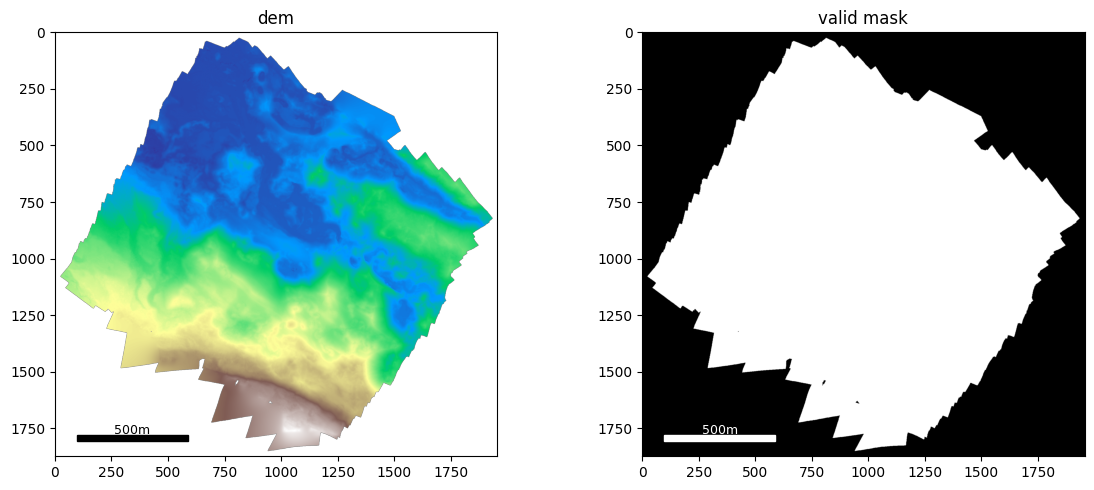

In [12]:
# visual check
fig, axes = plt. subplots(1,2, figsize=(12, 5))
dem_display = np.where(dem_array == dem_nodata, np.nan, dem_array)
axes[0].imshow(dem_display, cmap='terrain')
axes[0].set_title('dem')
add_scalebar(axes[0], pixel_size_m = pixel_size, length_m=500, color='black')

axes[1].imshow(valid_mask, cmap='gray')
axes[1].set_title('valid mask')
add_scalebar(axes[1], pixel_size_m = pixel_size, length_m=500, color='white')

plt.tight_layout()
plt.show()

In [13]:
## step 2 -- hydrological conditioning with pysheds

# initialize pysheds Grid from dem file
grid = Grid.from_raster(dem_path)
dem = grid.read_raster(dem_path)

print(f"grid shape: {grid.shape}")
print(f"dem dtype: {dem.dtype}")

grid shape: (1875, 1957)
dem dtype: float32


In [14]:
# fill pits -----
pits_filled = grid.fill_pits(dem)
print("pits filled")

# fill depressions ---
flooded = grid.fill_depressions(pits_filled)
print("depressions filled")

# resolve flats
inflated = grid.resolve_flats(flooded)
print("flats resolved")

print("hydrological conditioning complete")

pits filled
depressions filled
flats resolved
hydrological conditioning complete


In [15]:
### step 3 --- flow accumulations


# d8 dirmap: (NE, N, NW, W, SW, S, SE, E)
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# flow directions using MFD (Multiple Flow Direction)
fdir = grid.flowdir(inflated, dirmap=dirmap)
print(f"flow direction computed, unique values {np.unique(fdir)}")

# flow accumulations
acc = grid.accumulation(fdir, dirmap=dirmap)
print(f"flow accumulation range: {acc.min():.0f} to {acc.max():.0f}")

flow direction computed, unique values [ -2  -1   0   1   2   4   8  16  32  64 128]
flow accumulation range: 0 to 770938


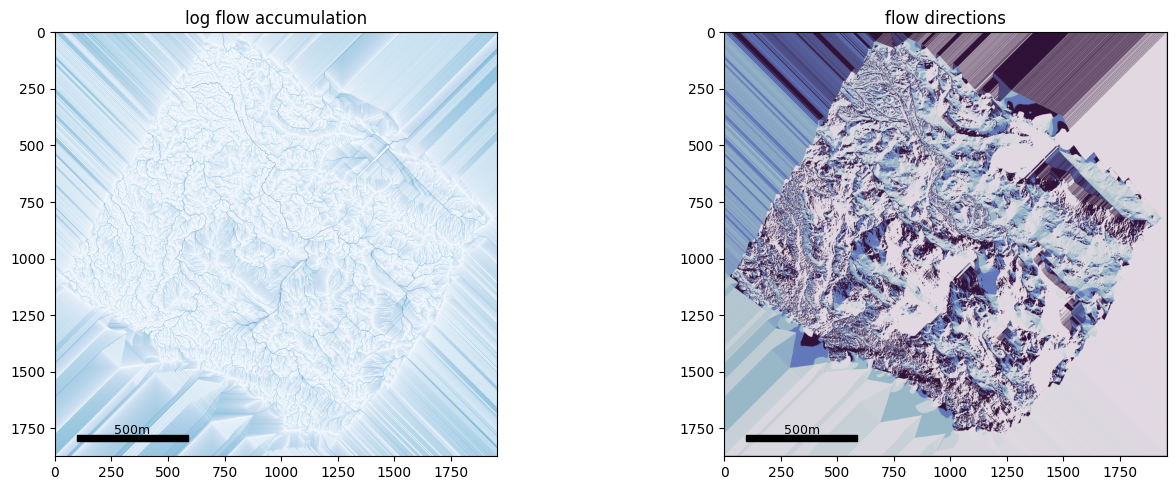

In [17]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(14,5))

acc_display = np.where(np.array(acc) <= 0, np.nan, np.log1p(np.array(acc)))
axes[0].imshow(acc_display, cmap='Blues')
axes[0].set_title('log flow accumulation')
add_scalebar(axes[0], pixel_size_m = pixel_size, length_m=500, color='black')

fdir_display = np.where(np.array(fdir) <= 0, np.nan, np.array(fdir))
axes[1].imshow(fdir_display, cmap='twilight')
axes[1].set_title('flow directions')
add_scalebar(axes[1], pixel_size_m = pixel_size, length_m=500, color='black')

plt.savefig("fig_micanwell_accdirs_mosext.png")
plt.tight_layout()
plt.show()

In [18]:
### step 4 ---- build sparse flow direction matrix and grid adjacency (simple) matrix

In [19]:
## map valid pixels to node indices
# valid mask is (1875, 1957) boolean array -- (changed with mosaic extent)
# we need a mapping: (row, col) -> node_index for valid pixels only

fdir_array = np.array(fdir)
valid = valid_mask.copy()

# create node index map -- -1 means invalid
node_index = np.full(valid.shape, -1, dtype=np.int32)
valid_coords = np.argwhere(valid) # shape (n_valid, 2) -- (row, col)
n_nodes = len(valid_coords)
node_index[valid_coords[:, 0], valid_coords[:,1]] = np.arange(n_nodes)

print(f"number of nodes: {n_nodes}")


number of nodes: 2041172


In [20]:
# --- D8 direction offsets ---
# dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
# correspond to (NE, N, NW, W, SW, S, SE, E)
d8_offsets = {
    64:  (-1,1),  #NE
    128: (-1,0),  #N
    1:   (-1,-1), #NW
    2:   ( 0,-1), #W
    4:   ( 1,-1), #SW
    8:   ( 1, 0), #S
    16:  ( 1, 1), #SE
    32:  ( 0, 1)  #E
}

In [21]:
### flow direction edge list ###

In [22]:
# all valid pixel coords #
rows = valid_coords[:,0]
cols = valid_coords[:,1]

In [23]:
# d8 offsets as arrays #
d8_dirs   = np.array([64,  128,  1,  2,  4, 8,  16, 32])
d8_dr     = np.array([-1,  -1,  -1,  0,  1, 1,  1,   0])
d8_dc     = np.array([ 1,   0,  -1, -1, -1, 0,  1,   1])
d8_dist   = np.sqrt(d8_dr**2 + d8_dc**2).astype(np.float32)

In [24]:
flow_src_list = []
flow_dst_list = []
flow_wgt_list = []

grid_src_list = []
grid_dst_list = []

for k in range(8): # each possible neighbor direction
    dr = d8_dr[k]
    dc = d8_dc[k]
    dist = d8_dist[k]

    # neighbor coordinates for all valid nodes
    nr = rows + dr
    nc = cols + dc

    # bounds check
    in_bounds = (nr >= 0) & (nr < valid.shape[0]) & \
                (nc >= 0) & (nc < valid.shape[1])

    # valid neighbor check
    nr_safe = np.where(in_bounds, nr, 0)
    nc_safe = np.where(in_bounds, nc, 0)
    neighbor_idx = node_index[nr_safe, nc_safe]
    has_valid_neighbor = in_bounds & (neighbor_idx >= 0)

    # source node indices
    src_idx = np.arange(n_nodes)

    # grid adjacency -- all valid neighbors
    mask = has_valid_neighbor
    grid_src_list.append(src_idx[mask])
    grid_dst_list.append(neighbor_idx[mask])

    # flow direction -- only where fdir matches this direction
    fdir_match = fdir_array[rows, cols] == d8_dirs[k]
    flow_mask = has_valid_neighbor & fdir_match

    if flow_mask.any():
        # slope weight
        elev_src = dem_array[rows[flow_mask], cols[flow_mask]]
        elev_dst = dem_array[nr_safe[flow_mask], nc_safe[flow_mask]]
        slope = (elev_src - elev_dst) / dist
        slope = np.maximum(slope, 0.0)

        flow_src_list.append(src_idx[flow_mask])
        flow_dst_list.append(neighbor_idx[flow_mask])
        flow_wgt_list.append(slope)

## concatenate ---
flow_src = np.concatenate(flow_src_list).astype(np.int64)
flow_dst = np.concatenate(flow_dst_list).astype(np.int64)
flow_wgt = np.concatenate(flow_wgt_list).astype(np.float32)

grid_src = np.concatenate(grid_src_list).astype(np.int64)
grid_dst = np.concatenate(grid_dst_list).astype(np.int64)
grid_wgt = np.ones(len(grid_src), dtype=np.float32)

"""
### use this only for true MFD ###
# normalize flow weights so each source node sums to 1
from numpy import bincount
weight_sum = bincount(flow_src, weights=flow_wgt, minlength=n_nodes)
weight_sum = np.maximum(weight_sum, 1e-10)
flow_wgt = flow_wgt / weight_sum[flow_src]
"""
print(f"flow edges: {len(flow_src)}")
print(f"grid edges: {len(grid_src)}")

flow edges: 2038332
grid edges: 16306088


In [25]:
# ---- save ----
np.save('flow_src_mosext.npy', flow_src)
np.save('flow_dst_mosext.npy', flow_dst)
np.save('flow_wgt_mosext.npy', flow_wgt)
np.save('grid_src_mosext.npy', grid_src)
np.save('grid_dst_mosext.npy', grid_dst)
np.save('valid_coords_mosext.npy', valid_coords)
np.save('node_index_mosext.npy', node_index)

print('saved')

saved


In [26]:
### node features ###

In [27]:
# elevation, mask nodata
elev = dem_array.copy().astype(np.float32)
elev[~valid_mask] = np.nan

In [28]:
# slope -- load from gdal preprocessing
with rasterio.open('data/MicaSlope_13Aug25_mosext.tif') as src:
    slope_array = src.read(1).astype(np.float32)
    slope_nodata = src.nodata
    
slope_array[~valid_mask] = np.nan
print(f"Slope range: {np.nanmin(slope_array):.3f} to {np.nanmax(slope_array):.3f}")

Slope range: 0.018 to 82.329


In [31]:
# aspect ---- load from gdal preprocessing
with rasterio.open('data/MicaAspect_13Aug25_mosext.tif') as src:
    aspect_array = src.read(1).astype(np.float32)
    aspect_nodata = src.nodata

aspect_array[~valid_mask] = np.nan

# convert to sin/cos components
# accounts for  0 ~ 360 identical but numerical difference
aspect_rad = np.radians(aspect_array)
aspect_sin = np.sin(aspect_rad)
aspect_cos = np.cos(aspect_rad)
print(f"Aspect range: {np.nanmin(aspect_rad):.1f} to {np.nanmax(aspect_rad):.1f}")
print(f"Aspect sin range: {np.nanmin(aspect_sin):.3f} to {np.nanmax(aspect_sin):.3f}")
print(f"Aspect cos range: {np.nanmin(aspect_cos):.3f} to {np.nanmax(aspect_cos):.3f}")

Aspect range: 0.0 to 6.3
Aspect sin range: -1.000 to 1.000
Aspect cos range: -1.000 to 1.000


In [33]:
# curvature 
from scipy.ndimage import sobel, generic_laplace, uniform_filter
# --- laplacian approximation ---
# laplacian = center - mean of neighbors
elev_clean = np.nan_to_num(elev)
elev_smooth = uniform_filter(elev_clean, size=3)
curvature = elev_clean - elev_smooth
curvature[~valid_mask] = np.nan

print(f"curvature range: {np.nanmin(curvature):.4f} to {np.nanmax(curvature):.4f}")

# remove boundary artifacts
# percentile clipping rather than fixed values
p1 = np.nanpercentile(curvature, 1)
p99 = np.nanpercentile(curvature, 99)
curvature_clipped = np.clip(curvature, p1, p99)
curvature_clipped[~valid_mask] = np.nan

print(f"curvature clipped range: {np.nanmin(curvature_clipped):.4f} to {np.nanmax(curvature_clipped):.4f}")

curvature range: -8.9384 to 743.8438
curvature clipped range: -0.1547 to 0.2178


In [34]:
# flow accumulation -- --
acc_array = np.array(acc).astype(np.float32)
acc_array[~valid_mask] = np.nan
# log transform -- accumulation spans orders of magnitude
log_acc = np.log1p(acc_array)

In [35]:
print("Topographic features computed")
print(f"Slope range: {np.nanmin(slope_array):.3f} to {np.nanmax(slope_array):.3f}")
print(f"Aspect range: {np.nanmin(aspect_rad):.1f} to {np.nanmax(aspect_rad):.1f}")
print(f"Aspect sin range: {np.nanmin(aspect_sin):.3f} to {np.nanmax(aspect_sin):.3f}")
print(f"Aspect cos range: {np.nanmin(aspect_cos):.3f} to {np.nanmax(aspect_cos):.3f}")
print(f"Curvature clipped range: {np.nanmin(curvature_clipped):.4f} to {np.nanmax(curvature_clipped):.4f}")
print(f"Log accumulation range: {np.nanmin(log_acc):.2f} to {np.nanmax(log_acc):.2f}")

Topographic features computed
Slope range: 0.018 to 82.329
Aspect range: 0.0 to 6.3
Aspect sin range: -1.000 to 1.000
Aspect cos range: -1.000 to 1.000
Curvature clipped range: -0.1547 to 0.2178
Log accumulation range: 0.69 to 13.56


In [37]:
### save progress ###
# -- extract valid pixels for each feature --
rows = valid_coords[:, 0]
cols = valid_coords[:, 1]

feat_elev       = elev[rows, cols]
feat_slope      = slope_array[rows, cols]
feat_aspect_sin = aspect_sin[rows, cols]
feat_aspect_cos = aspect_cos[rows, cols]
feat_curvature  = curvature_clipped[rows, cols]
feat_log_acc    = log_acc[rows, cols]

# --- stack into node feature matrix ---
node_features_topo = np.stack([
    feat_elev,
    feat_slope,
    feat_aspect_sin,
    feat_aspect_cos,
    feat_curvature,
    feat_log_acc
], axis=1).astype(np.float32)

print(f"topographic feature matrix shape: {node_features_topo.shape}")
print(f"nan count: {np.isnan(node_features_topo).sum()}")

topographic feature matrix shape: (2041172, 6)
nan count: 0


In [38]:
# save unscaled -- normalize later all together
np.save('node_features_topo.npy', node_features_topo)
# np.save('valid_coords_mosext.npy', valid_coords)
# np.save('node_index_mosext.npy', node_index)

print("saved node_features_topo.npy")

saved node_features_topo.npy


In [ ]:
valid_mask = np.load

In [ ]:
###### FLOW ROUTING WITH DIFF DEM ########

In [3]:
## route difference DEM through flow structure
# landscape memory feature

# load clipped diffDEM
difdem_path = 'data/CanDiff20002025_mosext.tif'

with rasterio.open(difdem_path) as src:
    diff_array = src.read(1).astype(np.float32)
    diff_nodata = src.nodata
    print(f"diff shape: {diff_array.shape}")
    print(f"diff nodata: {diff_nodata}")

# mask nodata
if diff_nodata is not None:
    diff_array[diff_array == diff_nodata] = np.nan
diff_array[~valid_mask] = np.nan

diff shape: (1875, 1957)
diff nodata: -32767.0


NameError: name 'valid_mask' is not defined

In [40]:
# apply Feynman's sign rule
# original difference DEM has POSITIVE values as glacier loss
# we flip to get NEGATIVE values as glacier loss
diff_array = - diff_array

In [43]:
## we want NEGATIVE pixels == loss
## consistent with intuition
print(f"diff range: {np.nanmin(diff_array):.3f} to {np.nanmax(diff_array):.3f}")
print(f"diff mean: {np.nanmean(diff_array):.3f}")
print(f"negative pixels (loss): {(diff_array <0).sum()}")
print(f"positive pixels (gain): {(diff_array >0).sum()}")

diff range: -88.039 to 19.717
diff mean: -16.619
negative pixels (loss): 1958201
positive pixels (gain): 73906


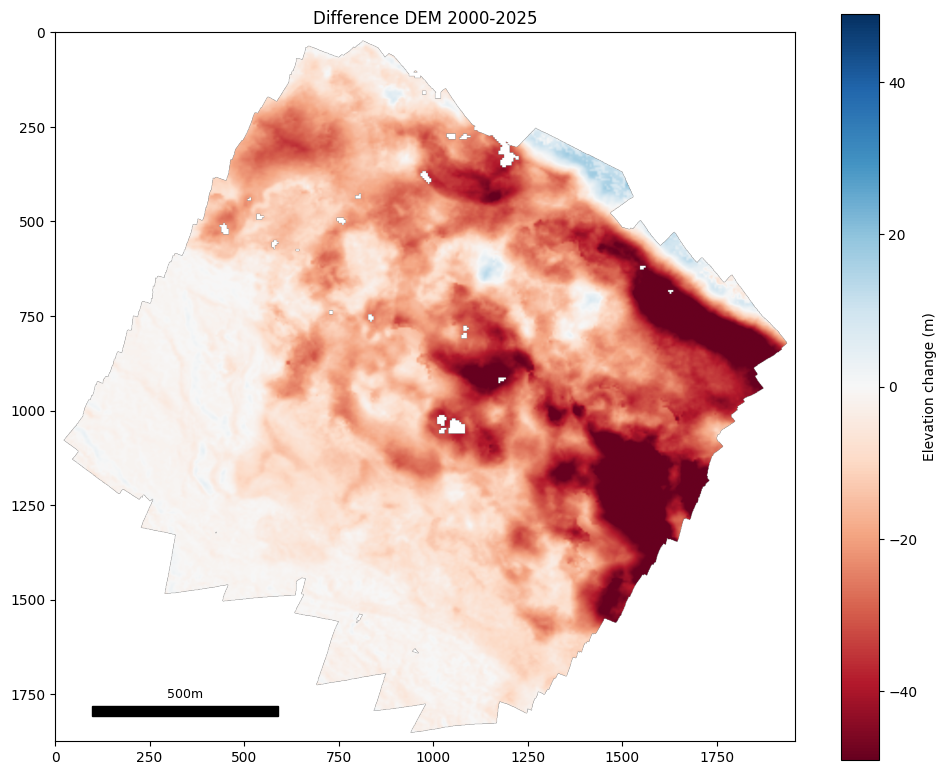

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
diff_display = diff_array.copy()
vmax = np.nanpercentile(np.abs(diff_display), 95)
im = ax.imshow(diff_display, cmap='RdBu', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Elevation change (m)')
ax.set_title('Difference DEM 2000-2025')
add_scalebar(ax, pixel_size_m=pixel_size, length_m=500, color='black')
# plt.savefig('fig_diffTerminus.png')
plt.tight_layout()
plt.show()

In [ ]:
############### ABANDON WATER MASKING AND FLOW ROUTING FOR NOW ########################

In [64]:
#### prepare for water masking ####

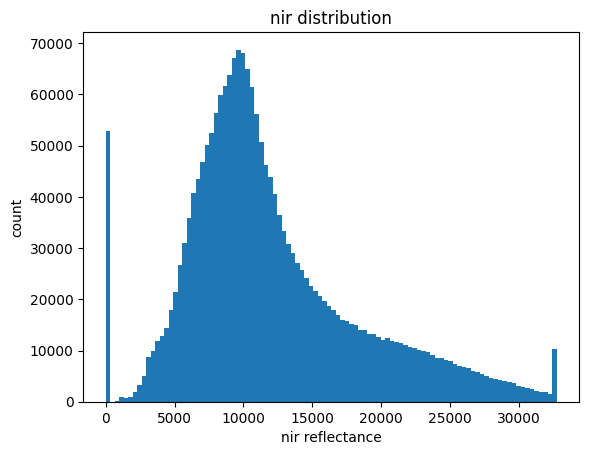

NIR range: 0.0 to 32767.0
NIR mean: 6748.6


In [72]:
with rasterio.open('data/CanwellTerminus081325.tif') as src:
    nir = src.read(6).astype(np.float32)
    nir_nodata = src.nodata

nir[nir == nir_nodata] = np.nan

# check nir distribution
nir_valid = nir[valid_mask]
plt.hist(nir_valid[~np.isnan(nir_valid)], bins=100)
plt.xlabel('nir reflectance')
plt.ylabel('count')
plt.title('nir distribution')
plt.show()

print(f"NIR range: {np.nanmin(nir):.1f} to {np.nanmax(nir):.1f}")
print(f"NIR mean: {np.nanmean(nir):.1f}")

In [ ]:
#### implement flow iterative routing #####

In [52]:
from scipy.sparse import csr_matrix, diags

# build sparse flow direction matrix M #
# normalized for flow routing only
# M[i,j] = normalized weight of flow from node i to node j
M = csr_matrix(
    (flow_wgt, (flow_src, flow_dst)),
    shape=(n_nodes, n_nodes),
    dtype = np.float32
)

print(f"M shape: {M.shape}")
print(f"M nonzero entries: {M.nnz}")

M shape: (2041172, 2041172)
M nonzero entries: 2038332


In [53]:
# prepare to normalize
row_sums = np.array(M.sum(axis=1)).flatten()
row_sums = np.maximum(row_sums, 1e-10)
D_inv    = diags(1.0 / row_sums)

print("D_inv ready")

D_inv ready


In [54]:
M_normalized = D_inv.dot(M)
print("normalized M ready")

# ── Verify ──
test_sums = np.array(M_normalized.sum(axis=1)).flatten()
print(f"Row sum range: {test_sums.min():.4f} to {test_sums.max():.4f}")
print(f"Sink nodes: {(test_sums == 0).sum()}")

normalized M ready
Row sum range: 0.0000 to 1.0000
Sink nodes: 878752


In [55]:
## initial condition w(0) = difference values at valid nodes
diff_valid = diff_array[valid_coords[:,0],
                        valid_coords[:,1]]

###### ASSUMPTION????? ########
# replace remaining nans with 0 -- no signal at the nodes
diff_valid = np.nan_to_num(diff_valid, nan=0.0).astype(np.float32)

print(f"diff signal range at nodes: {diff_valid.min():.3f} to {diff_valid.max():.3f}")
print(f"non-zero signal nodes: {(diff_valid !=0).sum()}")

diff signal range at nodes: -88.039 to 19.717
non-zero signal nodes: 2032107


In [59]:
# Find where max signal is occurring
max_idx = np.argmax(np.abs(w))
print(f"Max signal node: {max_idx}")
print(f"Node coordinates: {valid_coords[max_idx]}")
print(f"Is sink: {test_sums[max_idx] == 0}")
print(f"diff value at max node: {diff_valid[max_idx]:.3f}")
print(f"Elevation at max node: {node_features_topo[max_idx, 0]:.3f}")

Max signal node: 1498376
Node coordinates: [1232 1518]
Is sink: True
diff value at max node: -88.039
Elevation at max node: 830.739


In [60]:
# Look at the neighborhood around the sink
row, col = 1232, 1518
neighborhood = dem_array[row-5:row+6, col-5:col+6]
print("Elevation neighborhood (11x11):")
print(np.round(neighborhood, 2))

# Check flow directions around it
fdir_neighborhood = fdir_array[row-5:row+6, col-5:col+6]
print("\nFlow direction neighborhood:")
print(fdir_neighborhood)

# How many nodes drain into this sink?
sink_node = node_index[row, col]
incoming = (flow_dst == sink_node).sum()
print(f"\nIncoming edges to sink: {incoming}")

Elevation neighborhood (11x11):
[[832.35 832.33 832.3  832.27 832.22 832.06 831.7  831.17 830.71 830.37
  830.12]
 [832.34 832.32 832.24 832.07 831.82 831.54 831.22 830.87 830.57 830.29
  830.07]
 [832.27 832.26 832.15 831.89 831.47 831.11 830.87 830.67 830.48 830.27
  830.1 ]
 [832.17 832.15 831.98 831.6  831.18 830.88 830.73 830.59 830.41 830.23
  830.07]
 [832.03 831.97 831.71 831.3  830.95 830.76 830.66 830.52 830.33 830.15
  830.  ]
 [831.84 831.68 831.37 831.05 830.84 830.74 830.63 830.47 830.26 830.07
  829.93]
 [831.59 831.32 831.06 830.91 830.81 830.73 830.61 830.41 830.17 829.98
  829.85]
 [831.39 831.12 830.95 830.85 830.78 830.71 830.58 830.35 830.1  829.91
  829.78]
 [831.24 831.04 830.91 830.83 830.75 830.65 830.48 830.24 830.02 829.86
  829.73]
 [831.1  830.98 830.88 830.82 830.73 830.57 830.35 830.12 829.94 829.83
  829.71]
 [831.01 830.94 830.87 830.82 830.72 830.52 830.26 830.03 829.88 829.81
  829.69]]

Flow direction neighborhood:
[[128  64 128 128 128 128  64 128 1

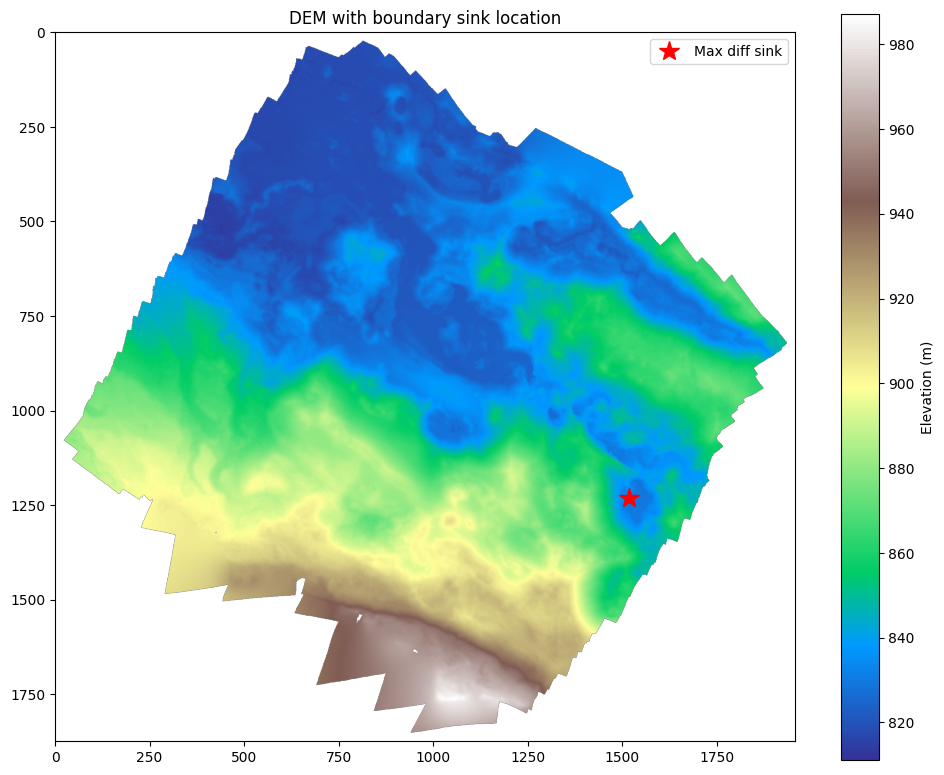

In [62]:
fig, ax = plt.subplots(figsize=(10, 8))
dem_display = np.where(valid_mask, dem_array, np.nan)
im = ax.imshow(dem_display, cmap='terrain')
plt.colorbar(im, ax=ax, label='Elevation (m)')

# Mark the sink node
ax.plot(1518, 1232, 'r*', markersize=15, label='Max diff sink')
ax.legend()
ax.set_title('DEM with boundary sink location')
add_scalebar(ax, pixel_size_m=pixel_size, length_m=500, color='white')
plt.savefig('fig_DEM_maxsink.png')
plt.tight_layout()
plt.show()

In [ ]:
### address non-convergence:
# 1. damping: set M = M*a where a in (0,1)
# interpretation: some fraction of signal is absorbed at each node
# drawback: treats every signal as same

In [56]:
### iterative routing:
# a = w(0) + M^T w(0) + (M^T)^2 w(0) + ...
# stop when update is negligible

MT = M.T # transpose for routing

w = diff_valid.copy()
accumulated = diff_valid.copy()

print("routing signal through flow network...")
max_iter = 10000
tol = 1e-4

for k in range(max_iter):
    w_new = MT.dot(w)
    accumulated += w_new

    # check convergence -- max absolute change
    delta = np.abs(w_new).max()

    if k % 100 == 0:
        print(f" Iteration {k}, max signal: {delta:.6f}")

    if delta < tol:
        print(f"converged at iteration {k}")
        break

    w - w_new

print(f"routed diff range: {accumulated.min():.3f} to {accumulated.max():.3f}")
print(f"routed diff mean: {accumulated.mean():.3f}")

routing signal through flow network...
 Iteration 0, max signal: 964.230713
 Iteration 100, max signal: 964.230713
 Iteration 200, max signal: 964.230713
 Iteration 300, max signal: 964.230713
 Iteration 400, max signal: 964.230713
 Iteration 500, max signal: 964.230713
 Iteration 600, max signal: 964.230713
 Iteration 700, max signal: 964.230713
 Iteration 800, max signal: 964.230713
 Iteration 900, max signal: 964.230713
 Iteration 1000, max signal: 964.230713
 Iteration 1100, max signal: 964.230713
 Iteration 1200, max signal: 964.230713
 Iteration 1300, max signal: 964.230713
 Iteration 1400, max signal: 964.230713
 Iteration 1500, max signal: 964.230713
 Iteration 1600, max signal: 964.230713
 Iteration 1700, max signal: 964.230713
 Iteration 1800, max signal: 964.230713
 Iteration 1900, max signal: 964.230713
 Iteration 2000, max signal: 964.230713
 Iteration 2100, max signal: 964.230713
 Iteration 2200, max signal: 964.230713
 Iteration 2300, max signal: 964.230713
 Iteration 24

# slope -- via sobel gradients
# sobel gradient in x and y directions
dz_dx = sobel(np.nan_to_num(elev), axis=1) / 8.0
dz_dy = sobel(np.nan_to_num(elev), axis=0) / 8.0
slope = np.sqrt(dz_dx**2 + dz_dy**2)
slope[~valid_mask] = np.nan

# aspect ----
aspect = np.arctan2(dz_dy, -dz_dx)
aspect_deg = np.degrees(aspect) % 360
aspect_deg[~valid_mask] = np.nan

In [9]:
# original load valid mask
'''
with rasterio.open(mask_path) as src:
    valid_mask = src.read(1).astype(bool)

print(f"valid pixels: {valid_mask.sum()} of {valid_mask.size} ({100*valid_mask.sum()/valid_mask.size:.1f}%)")
'''

'\nwith rasterio.open(mask_path) as src:\n    valid_mask = src.read(1).astype(bool)\n\nprint(f"valid pixels: {valid_mask.sum()} of {valid_mask.size} ({100*valid_mask.sum()/valid_mask.size:.1f}%)")\n'

In [31]:
#from scipy.ndimage import sobel, generic_laplace, uniform_filter

In [ ]:
## used to determine exact transform between DEM and mosaic
## everything should align off mosaic
for f in ['data/MicaDEM_13Aug26_1m.tif', 'data/CanwellTerminus081325.tif']:
    with rasterio.open(f) as src:
        print(f"\n{f}")
        print(f"CRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        print(f"Resolution: {src.res}")
        print(f"Transform: {src.transform}")